# Stemgedrag & Fractiediscipline

**Thema:** Stemmingen per besluit en de rol van de fracties.

**Kernvragen:** Hoe vaak stemmen fracties unaniem? Zijn er partijen die structureel tegen de meerderheid stemmen, en hoe verhoudt de fractiegrootte zich tot het stemgedrag (vergissingen daargelaten)?

Dit notebook verkent o.a. de silver-tabellen `stemming`, `besluit`, `fractie` en `besluit_zaak`.

In [1]:
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

def find_database(start: Path | None = None) -> Path:
    """Find the repository DuckDB database by walking up from the current folder."""
    current = (start or Path.cwd()).resolve()
    for folder in (current, *current.parents):
        candidate = folder / "tweedekamer.duckdb"
        if candidate.is_file():
            return candidate
    raise FileNotFoundError("Could not find tweedekamer.duckdb from the current directory")


database_path = find_database()
connection = duckdb.connect(str(database_path), read_only=True)


def query_df(sql: str, parameters=None) -> pd.DataFrame:
    """Execute a SQL query and return the result as a pandas DataFrame."""
    return connection.execute(sql, parameters or []).fetchdf()


database_path

Matplotlib is building the font cache; this may take a moment.


PosixPath('/Users/roossophie/first-contributions/tweedekamer-monitor/tweedekamer.duckdb')

## Onderwerp 1

Geef hier een beschrijving van het onderwerp of deelvraag die je wilt beantwoorden.

In [2]:
for tabel in ["stemming", "besluit", "fractie", "besluit_zaak"]:
    print(f"--- {tabel} ---")
    print(query_df(f"DESCRIBE silver.{tabel}"))
    print()

--- stemming ---
          column_name               column_type null  key default extra
0                  id                   VARCHAR   NO  PRI    None  None
1          besluit_id                   VARCHAR  YES  NaN    None  None
2               soort                   VARCHAR  YES  NaN    None  None
3     fractie_grootte                   INTEGER  YES  NaN    None  None
4          actor_naam                   VARCHAR  YES  NaN    None  None
5       actor_fractie                   VARCHAR  YES  NaN    None  None
6          vergissing                   BOOLEAN  YES  NaN    None  None
7       sid_actor_lid                   VARCHAR  YES  NaN    None  None
8   sid_actor_fractie                   VARCHAR  YES  NaN    None  None
9          persoon_id                   VARCHAR  YES  NaN    None  None
10         fractie_id                   VARCHAR  YES  NaN    None  None
11       gewijzigd_op  TIMESTAMP WITH TIME ZONE  YES  NaN    None  None
12   api_gewijzigd_op  TIMESTAMP WITH TIME ZONE

## Onderwerp 2

...

### Kernvraag 1: Hoe vaak stemmen fracties unaniem?

We bekijken per fractie en per besluit of alle leden hetzelfde stemden (bijvoorbeeld allemaal "Voor"). Vergissingen worden hierbij uitgesloten.

In [18]:
query = """
WITH fractie_stemmen AS (
    SELECT
        f.naam_nl AS partij,
        s.besluit_id,
        COUNT(DISTINCT s.soort) AS aantal_unieke_stemopties
    FROM silver.stemming s
    JOIN silver.fractie f ON s.fractie_id = f.id
    WHERE s.vergissing = FALSE
    GROUP BY f.naam_nl, s.besluit_id
)
SELECT
    partij,
    COUNT(*) AS totaal_besluiten,
    SUM(CASE WHEN aantal_unieke_stemopties = 1 THEN 1 ELSE 0 END) AS unanieme_besluiten,
    ROUND(100.0 * SUM(CASE WHEN aantal_unieke_stemopties = 1 THEN 1 ELSE 0 END) / COUNT(*), 1) AS percentage_unaniem
FROM fractie_stemmen
GROUP BY partij
ORDER BY percentage_unaniem DESC
"""
unanimiteit = query_df(query)
unanimiteit

,partij,totaal_besluiten,unanieme_besluiten,percentage_unaniem
0,Fractie Den Haan,11260,11260.0,100.0
1,Groep Kortenoeven/Hernandez,421,421.0,100.0
2,Van Klaveren,117,117.0,100.0
3,Klein,8101,8101.0,100.0
4,Progressief Nederland,1369,1369.0,100.0
5,BIJ1,11433,11433.0,100.0
6,Houwers,6900,6900.0,100.0
7,Krol,2956,2956.0,100.0
8,Groep Krol/van Kooten-Arissen,1154,1154.0,100.0
9,50PLUS/Klein,1215,1215.0,100.0


We ontdekten dat bijna elke partij rond de 99-100% unaniem stemt, zelfs grote partijen. Dit controleren we door te kijken hoeveel losse stemrijen er gemiddeld per fractie/besluit zijn:

In [44]:
query = """
SELECT
    aantal_stemmen_per_fractie_besluit,
    COUNT(*) AS aantal_voorkomens
FROM (
    SELECT besluit_id, fractie_id, COUNT(*) AS aantal_stemmen_per_fractie_besluit
    FROM silver.stemming
    GROUP BY besluit_id, fractie_id
)
GROUP BY aantal_stemmen_per_fractie_besluit
ORDER BY aantal_stemmen_per_fractie_besluit
"""
query_df(query)

,aantal_stemmen_per_fractie_besluit,aantal_voorkomens
0,1,932220
1,2,787
2,3,1547
3,4,283
4,5,712
5,6,99
6,7,193
7,8,90
8,9,475
9,10,86


**Bevinding:** 932.220 van de ~938.590 fractie/besluit-combinaties (99,3%) hebben maar 1 stemrij. Dit betekent dat bij de meeste besluiten één stem namens de hele fractie wordt geregistreerd (stemming bij handopsteken), in plaats van dat elk Kamerlid apart stemt. Onze eerste analyse is dus grotendeels een artefact van de data. We herhalen de analyse, nu alleen op hoofdelijke stemmingen (waar meerdere losse stemmen per fractie geregistreerd staan).

In [45]:
query = """
WITH fractie_stemmen AS (
    SELECT
        f.naam_nl AS partij,
        s.besluit_id,
        COUNT(*) AS aantal_stemmen,
        COUNT(DISTINCT s.soort) AS aantal_unieke_stemopties
    FROM silver.stemming s
    JOIN silver.fractie f ON s.fractie_id = f.id
    WHERE s.vergissing = FALSE
    GROUP BY f.naam_nl, s.besluit_id
    HAVING COUNT(*) > 1
)
SELECT
    partij,
    COUNT(*) AS totaal_hoofdelijke_besluiten,
    SUM(CASE WHEN aantal_unieke_stemopties = 1 THEN 1 ELSE 0 END) AS unanieme_besluiten,
    ROUND(100.0 * SUM(CASE WHEN aantal_unieke_stemopties = 1 THEN 1 ELSE 0 END) / COUNT(*), 1) AS percentage_unaniem
FROM fractie_stemmen
GROUP BY partij
HAVING COUNT(*) >= 5
ORDER BY percentage_unaniem ASC
"""
unanimiteit_hoofdelijk = query_df(query)
unanimiteit_hoofdelijk

,partij,totaal_hoofdelijke_besluiten,unanieme_besluiten,percentage_unaniem
0,Groep Van Haga,70,19.0,27.1
1,Volkspartij voor Vrijheid en Democratie,535,154.0,28.8
2,Partij van de Arbeid,409,121.0,29.6
3,Nieuw Sociaal Contract,96,33.0,34.4
4,Partij voor de Vrijheid,534,191.0,35.8
5,GroenLinks,394,155.0,39.3
6,Democraten 66,532,222.0,41.7
7,GroenLinks-PvdA,129,57.0,44.2
8,Christen-Democratisch Appèl,534,274.0,51.3
9,Socialistische Partij,532,326.0,61.3


<Figure size 1000x800 with 0 Axes>

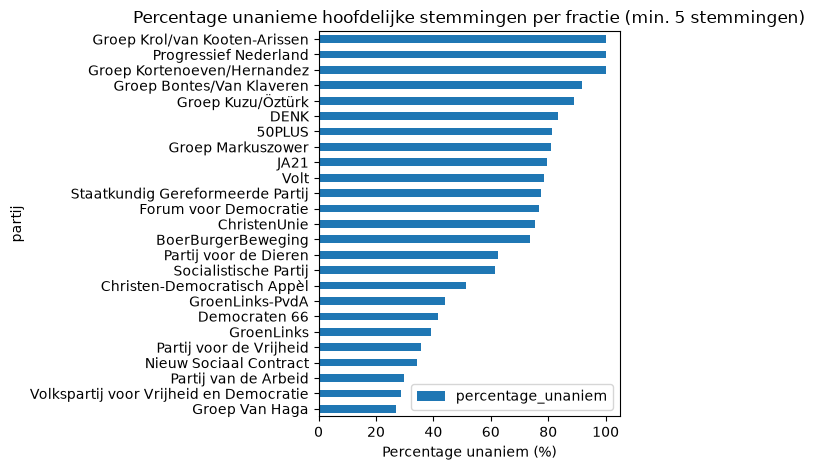

In [46]:
plt.figure(figsize=(10,8))
unanimiteit_hoofdelijk.sort_values("percentage_unaniem").plot.barh(
    x="partij", y="percentage_unaniem",
    title="Percentage unanieme hoofdelijke stemmingen per fractie (min. 5 stemmingen)"
)
plt.xlabel("Percentage unaniem (%)")
plt.tight_layout()
plt.show()

**Bevinding:** bij hoofdelijke stemmingen blijkt de fractiediscipline flink te verschillen. VVD, PvdA en Groep Van Haga stemmen het minst vaak unaniem binnen hun eigen fractie (27-30%), terwijl kleine homogene groepen altijd unaniem stemmen. Dit is een veel eerlijker beeld dan onze eerste analyse.

### Kernvraag 2: Zijn er partijen die structureel tegen de meerderheid stemmen?

Voor elk besluit bepalen we wat de meerderheid stemde (Voor of Tegen), gewogen naar fractiegrootte (zodat een stemming van 10 Kamerleden zwaarder telt dan 1). Daarna checken we per partij hoe vaak ze tegen die meerderheid instemden.

In [21]:
query = """
WITH fractie_stem AS (
    SELECT
        besluit_id,
        fractie_id,
        soort,
        SUM(COALESCE(fractie_grootte, 1)) AS gewicht,
        ROW_NUMBER() OVER (
            PARTITION BY besluit_id, fractie_id
            ORDER BY SUM(COALESCE(fractie_grootte, 1)) DESC
        ) AS rn
    FROM silver.stemming
    WHERE vergissing = FALSE AND soort IN ('Voor', 'Tegen')
    GROUP BY besluit_id, fractie_id, soort
),
fractie_definitief AS (
    SELECT besluit_id, fractie_id, soort, gewicht
    FROM fractie_stem
    WHERE rn = 1
),
besluit_stemmen AS (
    SELECT besluit_id, soort, SUM(gewicht) AS totaal_gewicht
    FROM fractie_definitief
    GROUP BY besluit_id, soort
),
meerderheid AS (
    SELECT
        besluit_id,
        soort AS meerderheid_soort,
        ROW_NUMBER() OVER (PARTITION BY besluit_id ORDER BY totaal_gewicht DESC) AS rn
    FROM besluit_stemmen
)
SELECT
    f.naam_nl AS partij,
    COUNT(*) AS totaal_besluiten,
    SUM(CASE WHEN fd.soort <> m.meerderheid_soort THEN 1 ELSE 0 END) AS tegen_meerderheid,
    ROUND(100.0 * SUM(CASE WHEN fd.soort <> m.meerderheid_soort THEN 1 ELSE 0 END) / COUNT(*), 1) AS percentage_tegen_meerderheid
FROM fractie_definitief fd
JOIN meerderheid m ON fd.besluit_id = m.besluit_id AND m.rn = 1
JOIN silver.fractie f ON fd.fractie_id = f.id
GROUP BY f.naam_nl
HAVING COUNT(*) >= 20
ORDER BY percentage_tegen_meerderheid DESC
"""
tegen_meerderheid = query_df(query)
tegen_meerderheid

,partij,totaal_besluiten,tegen_meerderheid,percentage_tegen_meerderheid
0,Partij voor de Dieren,63268,28724.0,45.4
1,Forum voor Democratie,37994,17221.0,45.3
2,Ephraim,286,126.0,44.1
3,Socialistische Partij,63373,27287.0,43.1
4,Bontes,1499,641.0,42.8
5,Groep Bontes/Van Klaveren,9651,4108.0,42.6
6,Groep Van Haga,11109,4718.0,42.5
7,50PLUS/Baay-Timmerman,1215,516.0,42.5
8,Groep Markuszower,3832,1604.0,41.9
9,BIJ1,9875,4082.0,41.3


<Figure size 1000x1000 with 0 Axes>

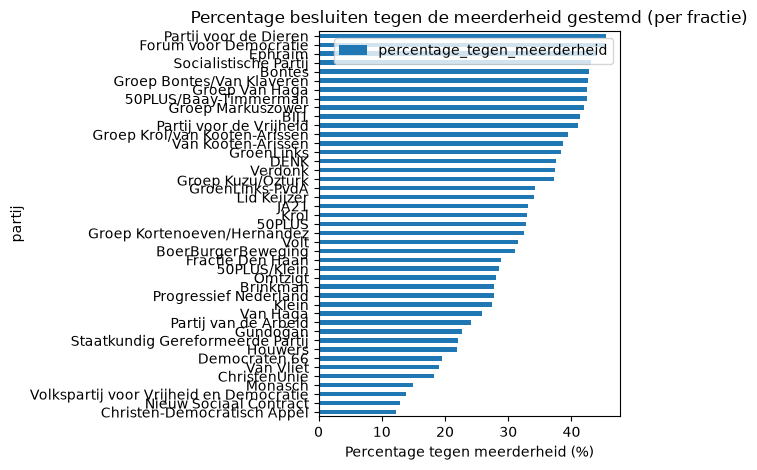

In [22]:
plt.figure(figsize=(10,10))
tegen_meerderheid.sort_values("percentage_tegen_meerderheid").plot.barh(
    x="partij", y="percentage_tegen_meerderheid",
    title="Percentage besluiten tegen de meerderheid gestemd (per fractie)"
)
plt.xlabel("Percentage tegen meerderheid (%)")
plt.tight_layout()
plt.show()

**Bevinding:** Partij voor de Dieren, Forum voor Democratie en SP stemmen het vaakst tegen de gewogen meerderheid (43-45%) — logisch voor structurele oppositiepartijen. VVD, CDA en ChristenUnie stemmen het vaakst mee met de meerderheid (13-22%), passend bij hun coalitierol.

### Kernvraag 3: hoe verhoudt fractiegrootte zich tot stemgedrag?

We onderzoeken of er een verband is tussen de grootte van een fractie (aantal zetels) en hoe vaak ze tegen de gewogen meerderheid stemmen.

We proberen eerst het aantal zetels op te halen via de kolom `aantal_zetels` in de `fractie`-tabel, gekoppeld aan het aantal besluiten waarop elke fractie heeft gestemd.

In [37]:
query = """
SELECT
    f.naam_nl AS partij,
    f.aantal_zetels,
    COUNT(*) AS totaal_besluiten
FROM silver.fractie f
JOIN silver.stemming s ON s.fractie_id = f.id
WHERE s.vergissing = FALSE
GROUP BY f.naam_nl, f.aantal_zetels
"""
zetels = query_df(query)
zetels

,partij,aantal_zetels,totaal_besluiten
0,Volkspartij voor Vrijheid en Democratie,22,79336
1,Christen-Democratisch Appèl,18,71281
2,ChristenUnie,3,65202
3,JA21,9,24330
4,Groep Kuzu/Öztürk,0,8110
5,Fractie Den Haan,0,11260
6,Progressief Nederland,20,1559
7,50PLUS/Klein,<NA>,1215
8,Monasch,0,1553
9,Brinkman,<NA>,1168


**Datakwaliteit-opmerking:** de kolom `aantal_zetels` bleek niet bruikbaar — grote, bekende partijen zoals PvdA en GroenLinks stonden op 0 zetels. We vermoeden dat de `fractie`-tabel een aparte rij bevat per periode/samenstelling van een fractie, en verifiëren dit met de actieve/inactieve periodes van deze fracties:

In [40]:
query = """
SELECT naam_nl, datum_actief, datum_inactief, aantal_zetels
FROM silver.fractie
WHERE naam_nl IN ('Partij van de Arbeid', 'GroenLinks', 'GroenLinks-PvdA', 'Progressief Nederland')
ORDER BY datum_actief
"""
query_df(query)

,naam_nl,datum_actief,datum_inactief,aantal_zetels
0,Partij van de Arbeid,1946-02-09,2023-10-26,0
1,GroenLinks,1990-11-24,2023-10-26,0
2,GroenLinks-PvdA,2023-10-27,2026-06-10,20
3,Progressief Nederland,2026-06-09,NaT,20


Dit bevestigt het vermoeden: PvdA en GroenLinks waren actief tot 26-10-2023, waarna ze fuseerden tot "GroenLinks-PvdA" (vanaf 27-10-2023), wat op zijn beurt overging in "Progressief Nederland" vanaf 09-06-2026. De oudere, inactieve fracties tonen daardoor 0 zetels, omdat `aantal_zetels` het meest recente aantal weergeeft, niet het aantal tijdens elke specifieke stemming.

Om deze reden gebruiken we in plaats daarvan de kolom `fractie_grootte` uit de `stemming`-tabel zelf. Deze geeft de fractiegrootte op het moment van elke specifieke stemming, en is daardoor betrouwbaarder voor deze analyse. We berekenen per partij de gemiddelde fractiegrootte over alle stemmingen (met minimaal 100 stemmen, om kleine/kortdurende fracties uit te sluiten).

In [41]:
query = """
WITH fractie_grootte_gemiddeld AS (
    SELECT
        f.naam_nl AS partij,
        AVG(s.fractie_grootte) AS gemiddelde_fractiegrootte,
        COUNT(*) AS totaal_stemmen
    FROM silver.stemming s
    JOIN silver.fractie f ON s.fractie_id = f.id
    WHERE s.vergissing = FALSE AND s.fractie_grootte IS NOT NULL
    GROUP BY f.naam_nl
    HAVING COUNT(*) >= 100
)
SELECT * FROM fractie_grootte_gemiddeld
ORDER BY gemiddelde_fractiegrootte DESC
"""
fractiegrootte = query_df(query)
fractiegrootte

,partij,gemiddelde_fractiegrootte,totaal_stemmen
0,Volkspartij voor Vrijheid en Democratie,31.807452,79336
1,GroenLinks-PvdA,23.698347,13973
2,Partij van de Arbeid,22.165948,57952
3,Partij voor de Vrijheid,20.261003,74091
4,Progressief Nederland,20.000000,1559
5,Nieuw Sociaal Contract,19.784053,9845
6,Christen-Democratisch Appèl,17.124956,71281
7,Democraten 66,15.816052,71254
8,Socialistische Partij,12.486081,68970
9,GroenLinks,8.932089,54395


We combineren deze fractiegrootte-data met de resultaten van kernvraag 2 (percentage tegen de meerderheid gestemd per partij), zodat we beide variabelen naast elkaar kunnen zetten.

In [42]:
combinatie = fractiegrootte.merge(tegen_meerderheid, on="partij", how="inner")
combinatie

,partij,gemiddelde_fractiegrootte,totaal_stemmen,totaal_besluiten,tegen_meerderheid,percentage_tegen_meerderheid
0,Volkspartij voor Vrijheid en Democratie,31.807452,79336,63404,8795.0,13.9
1,GroenLinks-PvdA,23.698347,13973,11042,3785.0,34.3
2,Partij van de Arbeid,22.165948,57952,50955,12276.0,24.1
3,Partij voor de Vrijheid,20.261003,74091,63292,25946.0,41.0
4,Progressief Nederland,20.000000,1559,1369,381.0,27.8
5,Nieuw Sociaal Contract,19.784053,9845,8035,1034.0,12.9
6,Christen-Democratisch Appèl,17.124956,71281,63355,7811.0,12.3
7,Democraten 66,15.816052,71254,63342,12344.0,19.5
8,Socialistische Partij,12.486081,68970,63373,27287.0,43.1
9,GroenLinks,8.932089,54395,50935,19582.0,38.4


We zetten dit uit in een scatter-plot: op de x-as de gemiddelde fractiegrootte, op de y-as het percentage tegen de meerderheid gestemd. Zo zien we of er een patroon is tussen fractiegrootte en afwijkend stemgedrag.

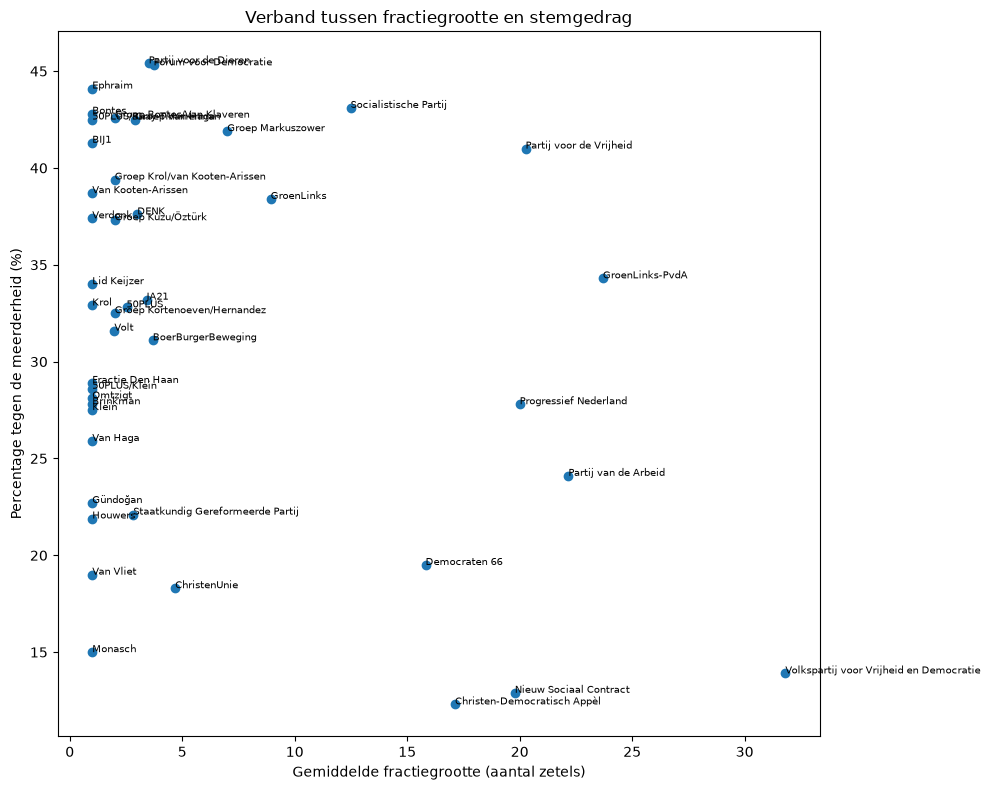

In [43]:
plt.figure(figsize=(10, 8))
plt.scatter(combinatie["gemiddelde_fractiegrootte"], combinatie["percentage_tegen_meerderheid"])

for _, rij in combinatie.iterrows():
    plt.annotate(rij["partij"], (rij["gemiddelde_fractiegrootte"], rij["percentage_tegen_meerderheid"]), fontsize=7)

plt.xlabel("Gemiddelde fractiegrootte (aantal zetels)")
plt.ylabel("Percentage tegen de meerderheid (%)")
plt.title("Verband tussen fractiegrootte en stemgedrag")
plt.tight_layout()
plt.show()

**Bevinding:** er is een duidelijk negatief verband tussen fractiegrootte en het percentage keren dat een fractie tegen de (gewogen) meerderheid stemt. Kleine fracties en eenmansfracties (zoals Ephraim, Bontes, en diverse afsplitsingen) stemmen 35-46% van de tijd tegen de meerderheid, terwijl grote, vaak regerende partijen zoals VVD (13,9%), CDA en Nieuw Sociaal Contract (beide rond de 13%) juist veruit het vaakst met de meerderheid meestemmen.

Dit patroon is goed te verklaren: grote partijen vormen vaker zelf de coalitie en dus de meerderheid (ze stemmen als het ware "met zichzelf mee"), terwijl kleine partijen vaker in de oppositie zitten en zich dus logischerwijs vaker tegen het meerderheidsstandpunt afzetten. Fractiegrootte en coalitie-/oppositierol lijken hier sterk met elkaar samen te hangen, wat ook al naar voren kwam bij kernvraag 2.

### Deelvraag 1: welke partijen staan qua stemgedrag het dichtst bij elkaar?

We berekenen voor elk paar fracties het percentage besluiten waarop ze hetzelfde stemden (Voor/Tegen), en vergelijken dit met hun politieke positionering.

**Stap 1 data ophalen in lang formaat:**

In [23]:
query = """
WITH fractie_stem AS (
    SELECT
        besluit_id,
        fractie_id,
        soort,
        SUM(COALESCE(fractie_grootte, 1)) AS gewicht,
        ROW_NUMBER() OVER (
            PARTITION BY besluit_id, fractie_id
            ORDER BY SUM(COALESCE(fractie_grootte, 1)) DESC
        ) AS rn
    FROM silver.stemming
    WHERE vergissing = FALSE AND soort IN ('Voor', 'Tegen')
    GROUP BY besluit_id, fractie_id, soort
)
SELECT f.naam_nl AS partij, fs.besluit_id, fs.soort
FROM fractie_stem fs
JOIN silver.fractie f ON fs.fractie_id = f.id
WHERE fs.rn = 1
"""
stemmen_lang = query_df(query)
stemmen_lang.shape

(928992, 3)

**Stap 2 omzetten naar een partij × besluit tabel, alleen grote/lang-actieve partijen:**

In [24]:
pivot = stemmen_lang.pivot_table(index="besluit_id", columns="partij", values="soort", aggfunc="first")

# alleen partijen met genoeg stemmen meenemen, anders is de vergelijking onbetrouwbaar
aantal_per_partij = pivot.notna().sum().sort_values(ascending=False)
print(aantal_per_partij)

partij
Volkspartij voor Vrijheid en Democratie    63404
Staatkundig Gereformeerde Partij           63388
Socialistische Partij                      63373
Christen-Democratisch Appèl                63355
Democraten 66                              63342
ChristenUnie                               63322
Partij voor de Vrijheid                    63292
Partij voor de Dieren                      63268
Partij van de Arbeid                       50955
GroenLinks                                 50935
DENK                                       38250
Forum voor Democratie                      37994
50PLUS                                     31638
Volt                                       23818
BoerBurgerBeweging                         23741
JA21                                       23546
Groep Van Haga                             11109
GroenLinks-PvdA                            11042
Fractie Den Haan                           10648
BIJ1                                        9875
Groep Bontes/

**Stap 3 bereken de overeenkomst-matrix:**

In [25]:
grote_partijen = aantal_per_partij[aantal_per_partij >= 20000].index.tolist()
pivot_groot = pivot[grote_partijen]

overeenkomst = pd.DataFrame(index=grote_partijen, columns=grote_partijen, dtype=float)

for p1 in grote_partijen:
    for p2 in grote_partijen:
        if p1 == p2:
            overeenkomst.loc[p1, p2] = 100.0
            continue
        beide_gestemd = pivot_groot[[p1, p2]].dropna()
        if len(beide_gestemd) > 0:
            gelijk = (beide_gestemd[p1].values == beide_gestemd[p2].values).mean()
            overeenkomst.loc[p1, p2] = round(gelijk * 100, 1)

overeenkomst

,Volkspartij voor Vrijheid en Democratie,Staatkundig Gereformeerde Partij,Socialistische Partij,Christen-Democratisch Appèl,Democraten 66,ChristenUnie,Partij voor de Vrijheid,Partij voor de Dieren,Partij van de Arbeid,GroenLinks,DENK,Forum voor Democratie,50PLUS,Volt,BoerBurgerBeweging,JA21
Volkspartij voor Vrijheid en Democratie,100.0,73.6,45.7,82.4,71.6,71.5,59.5,43.1,62.2,49.4,53.6,54.8,58.1,60.3,67.4,67.5
Staatkundig Gereformeerde Partij,73.6,100.0,55.9,78.7,68.2,76.9,61.3,53.1,65.8,58.4,61.0,62.3,67.5,60.9,76.4,74.7
Socialistische Partij,45.7,55.9,100.0,54.2,65.1,64.2,49.2,87.5,73.0,82.7,83.0,50.0,75.7,81.2,59.5,50.8
Christen-Democratisch Appèl,82.4,78.7,54.2,100.0,77.0,81.7,56.2,52.1,65.3,57.5,59.5,52.8,66.6,66.5,64.7,64.0
Democraten 66,71.6,68.2,65.1,77.0,100.0,80.9,46.1,65.9,71.7,73.6,66.0,47.1,68.7,79.1,56.7,55.5
ChristenUnie,71.5,76.9,64.2,81.7,80.9,100.0,50.2,63.0,69.9,68.4,65.1,51.3,70.7,73.2,64.0,61.5
Partij voor de Vrijheid,59.5,61.3,49.2,56.2,46.1,50.2,100.0,44.9,48.4,45.0,51.8,73.9,55.5,44.9,73.3,75.0
Partij voor de Dieren,43.1,53.1,87.5,52.1,65.9,63.0,44.9,100.0,73.3,86.3,81.0,45.3,73.3,83.1,53.2,45.2
Partij van de Arbeid,62.2,65.8,73.0,65.3,71.7,69.9,48.4,73.3,100.0,81.1,83.8,48.0,72.2,92.6,66.8,51.1
GroenLinks,49.4,58.4,82.7,57.5,73.6,68.4,45.0,86.3,81.1,100.0,83.5,46.5,76.6,92.8,66.5,51.0


**Stap 4 visualiseer als heatmap:**

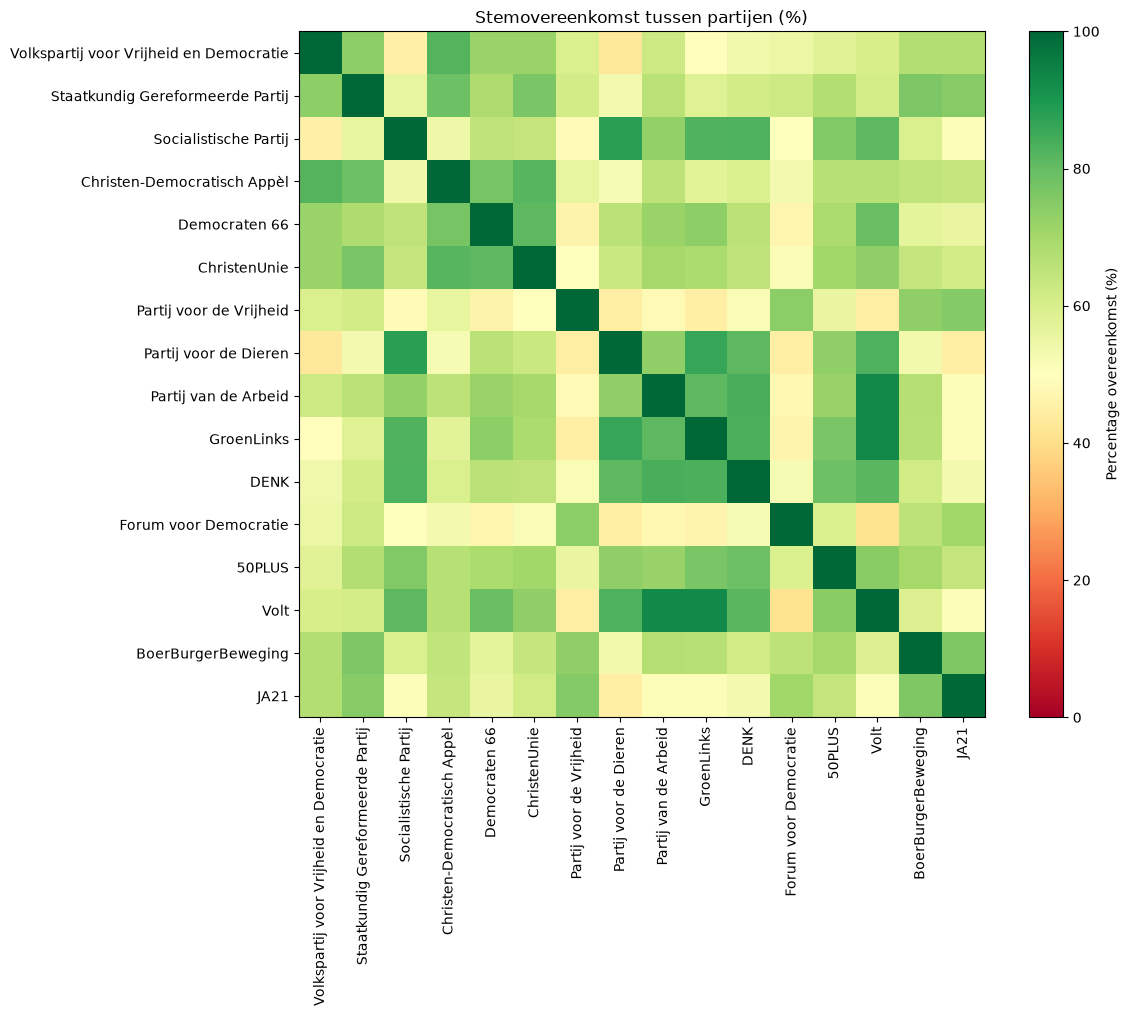

In [26]:
plt.figure(figsize=(12,10))
plt.imshow(overeenkomst.astype(float), cmap="RdYlGn", vmin=0, vmax=100)
plt.colorbar(label="Percentage overeenkomst (%)")
plt.xticks(range(len(grote_partijen)), grote_partijen, rotation=90)
plt.yticks(range(len(grote_partijen)), grote_partijen)
plt.title("Stemovereenkomst tussen partijen (%)")
plt.tight_layout()
plt.show()

**Stap 5 de meest/minst overeenkomende paren op een rijtje:**

In [27]:
paren = []
for i, p1 in enumerate(grote_partijen):
    for p2 in grote_partijen[i+1:]:
        paren.append((p1, p2, overeenkomst.loc[p1, p2]))

paren_df = pd.DataFrame(paren, columns=["partij_1", "partij_2", "overeenkomst_pct"]).sort_values("overeenkomst_pct", ascending=False)

print("Meest overeenkomend:")
print(paren_df.head(10))
print("\nMinst overeenkomend:")
print(paren_df.tail(10))

Meest overeenkomend:
                                    partij_1                     partij_2  \
102                               GroenLinks                         Volt   
96                      Partij van de Arbeid                         Volt   
33                     Socialistische Partij        Partij voor de Dieren   
85                     Partij voor de Dieren                   GroenLinks   
93                      Partij van de Arbeid                         DENK   
99                                GroenLinks                         DENK   
89                     Partij voor de Dieren                         Volt   
36                     Socialistische Partij                         DENK   
35                     Socialistische Partij                   GroenLinks   
2    Volkspartij voor Vrijheid en Democratie  Christen-Democratisch Appèl   

     overeenkomst_pct  
102              92.8  
96               92.6  
33               87.5  
85               86.3  
93         

**Bevinding:** de stemovereenkomst tussen partijen volgt grotendeels het verwachte politieke spectrum. Progressief-linkse partijen (GroenLinks, PvdA, Volt, SP, PvdD, DENK) stemmen onderling sterk overeen (83-93%), terwijl partijen van tegenovergestelde zijden van het spectrum (bijv. GroenLinks/PvdD tegenover Forum voor Democratie, of VVD tegenover SP) juist het minst overeenkomen (41-46%). Dit bevestigt dat stemgedrag in de praktijk goed aansluit bij de politieke positionering van partijen — met als kanttekening dat VVD en CDA, traditioneel middenpartijen, relatief hoog scoren met elkaar (82%), wat past bij hun geschiedenis van gezamenlijke coalitiedeelname.

### Deelvraag 2: welke Kamerleden wijken het vaakst af van hun eigen fractie?

We kijken alleen naar hoofdelijke stemmingen (waar leden individueel stemden), bepalen de meerderheidsstem per fractie per besluit, en tellen per Kamerlid hoe vaak ze daarvan afweken.

In [28]:
query = """
WITH individuele_stemmen AS (
    SELECT
        s.besluit_id,
        s.fractie_id,
        s.persoon_id,
        s.actor_naam,
        s.soort,
        COUNT(*) OVER (PARTITION BY s.besluit_id, s.fractie_id) AS fractie_grootte_stemming
    FROM silver.stemming s
    WHERE s.vergissing = FALSE AND s.soort IN ('Voor', 'Tegen') AND s.persoon_id IS NOT NULL
),
fractie_meerderheid AS (
    SELECT
        besluit_id, fractie_id, soort,
        ROW_NUMBER() OVER (
            PARTITION BY besluit_id, fractie_id
            ORDER BY COUNT(*) DESC
        ) AS rn
    FROM individuele_stemmen
    WHERE fractie_grootte_stemming > 1
    GROUP BY besluit_id, fractie_id, soort
),
meerderheid AS (
    SELECT besluit_id, fractie_id, soort AS meerderheid_soort
    FROM fractie_meerderheid WHERE rn = 1
)
SELECT
    f.naam_nl AS partij,
    i.actor_naam AS kamerlid,
    COUNT(*) AS totaal_hoofdelijke_stemmen,
    SUM(CASE WHEN i.soort <> m.meerderheid_soort THEN 1 ELSE 0 END) AS afwijkingen,
    ROUND(100.0 * SUM(CASE WHEN i.soort <> m.meerderheid_soort THEN 1 ELSE 0 END) / COUNT(*), 1) AS percentage_afwijking
FROM individuele_stemmen i
JOIN meerderheid m ON i.besluit_id = m.besluit_id AND i.fractie_id = m.fractie_id
JOIN silver.fractie f ON i.fractie_id = f.id
WHERE i.fractie_grootte_stemming > 1
GROUP BY f.naam_nl, i.actor_naam
HAVING COUNT(*) >= 10
ORDER BY percentage_afwijking DESC
LIMIT 25
"""
afwijkers = query_df(query)
afwijkers

,partij,kamerlid,totaal_hoofdelijke_stemmen,afwijkingen,percentage_afwijking
0,JA21,"Ceulemans, S.",43,6.0,14.0
1,JA21,"Nanninga, A.",43,6.0,14.0
2,JA21,"Berg van den, D.J.",43,6.0,14.0
3,JA21,"Boomsma, D.T. (Diederik)",43,6.0,14.0
4,Partij van de Arbeid,Smeets P.E.,15,2.0,13.3
5,Volkspartij voor Vrijheid en Democratie,"Ree van der, D.A.",15,1.0,6.7
6,BoerBurgerBeweging,"Helder, L.M.J.S.",42,2.0,4.8
7,Volkspartij voor Vrijheid en Democratie,"Bosma, R.P.G. (Remco)",30,1.0,3.3
8,JA21,"Eerdmans, B.J.",107,3.0,2.8
9,Partij voor de Vrijheid,"Kortenoeven, W.R.F.",37,1.0,2.7


Opvallend: "Boomsma, D.T. (Diederik)" komt voor bij zowel JA21 als Nieuw Sociaal Contract. We controleren of dit een datafout of een politieke overstap is:

In [29]:
query = """
SELECT DISTINCT i.actor_naam, f.naam_nl AS partij, COUNT(*) AS aantal_stemmen
FROM silver.stemming i
JOIN silver.fractie f ON i.fractie_id = f.id
WHERE i.actor_naam = 'Boomsma, D.T. (Diederik)'
GROUP BY i.actor_naam, f.naam_nl
ORDER BY aantal_stemmen DESC
"""
query_df(query)

,actor_naam,partij,aantal_stemmen
0,"Boomsma, D.T. (Diederik)",Nieuw Sociaal Contract,74
1,"Boomsma, D.T. (Diederik)",JA21,43


**Bevinding:** Kamerleden wijken zelden af van hun fractie (meeste percentages onder de 15%). Diederik Boomsma komt voor bij zowel JA21 (43 stemmen) als Nieuw Sociaal Contract (74 stemmen) dit bleek een politieke overstap tussen fracties, geen datafout. Dit laat zien dat bij dit soort analyses rekening gehouden moet worden met Kamerleden die van fractie wisselen.

### Deelvraag 3: over welk type zaak wordt het vaakst verdeeld gestemd?

We koppelen besluiten via `besluit_zaak` aan de `zaak`-tabel, om te zien of bepaalde soorten zaken (bijv. moties, wetsvoorstellen) vaker tot verdeelde stemmingen leiden dan andere.

stap 1: per besluit bepalen of er verdeeld gestemd is

In [47]:
query = """
WITH besluit_stemtypes AS (
    SELECT besluit_id, COUNT(DISTINCT soort) AS aantal_stemopties
    FROM silver.stemming
    WHERE vergissing = FALSE AND soort IN ('Voor', 'Tegen')
    GROUP BY besluit_id
),
besluit_met_zaak AS (
    SELECT bz.besluit_id, z.soort AS zaaksoort, bs.aantal_stemopties
    FROM silver.besluit_zaak bz
    JOIN silver.zaak z ON bz.zaak_id = z.id
    JOIN besluit_stemtypes bs ON bz.besluit_id = bs.besluit_id
)
SELECT
    zaaksoort,
    COUNT(*) AS totaal_besluiten,
    SUM(CASE WHEN aantal_stemopties > 1 THEN 1 ELSE 0 END) AS verdeeld_gestemd,
    ROUND(100.0 * SUM(CASE WHEN aantal_stemopties > 1 THEN 1 ELSE 0 END) / COUNT(*), 1) AS percentage_verdeeld
FROM besluit_met_zaak
GROUP BY zaaksoort
HAVING COUNT(*) >= 50
ORDER BY percentage_verdeeld DESC
"""
verdeeld_per_zaaksoort = query_df(query)
verdeeld_per_zaaksoort

,zaaksoort,totaal_besluiten,verdeeld_gestemd,percentage_verdeeld
0,Brief van lid/fractie/commissie,209,199.0,95.2
1,Amendement,8253,7510.0,91.0
2,Initiatiefwetgeving,124,111.0,89.5
3,Brief Kamer,55,49.0,89.1
4,Motie,52224,46471.0,89.0
5,Wetgeving,1635,1116.0,68.3
6,Begroting,675,440.0,65.2
7,Overig,223,138.0,61.9


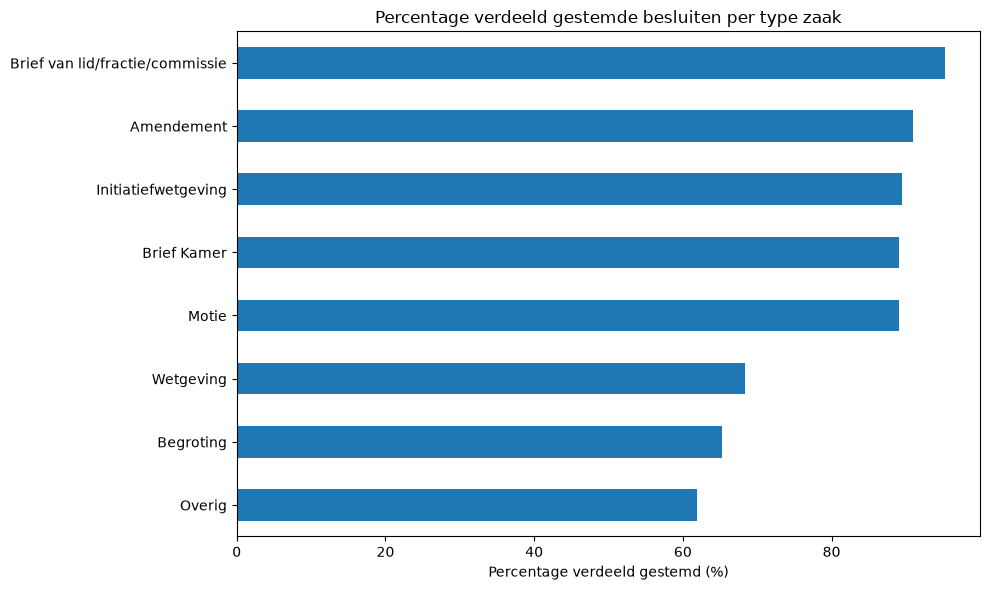

In [48]:
plt.figure(figsize=(10, 6))
verdeeld_per_zaaksoort.sort_values("percentage_verdeeld").plot.barh(
    x="zaaksoort", y="percentage_verdeeld",
    title="Percentage verdeeld gestemde besluiten per type zaak",
    legend=False, ax=plt.gca()
)
plt.xlabel("Percentage verdeeld gestemd (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Bevinding:** moties (89,0%) en amendementen (91,0%) worden veruit het vaakst verdeeld gestemd, terwijl uiteindelijke wetgeving (68,3%) en begrotingen (65,2%) juist vaker op bredere steun kunnen rekenen. Dit is goed te verklaren: moties en amendementen zijn vaak bedoeld om een specifiek (politiek) punt te maken en zijn daardoor polariserender van aard, terwijl wetgeving meestal al door een proces van onderhandeling en compromis is gegaan voordat het tot een eindstemming komt.